In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import numpy as np
import ad_tools.tools as tools
import matplotlib.pyplot as plt
import sklearn
import awkward as ak 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [29]:
class BetaVAEMark8Encoder(nn.Module):
    """
    Beta VAE Mark 8 Encoder 
    """
    def __init__(self, latent_dim = 7, log_clamping = True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.dense1 = nn.Linear(256, 64)
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))
        self.log_clamping = log_clamping


    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)



        # Latent space mapping
        output13 = self.flatten(output12)
        output14 = self.dense1(output13)
        output15 = F.leaky_relu(output14)
        mu = self.mu(output15)
        logvar = self.logvar(output15)
        if self.log_clamping:
            logvar = torch.clamp(logvar,-10,5)
        
        return mu, logvar,indices1,indices2,indices3

    
class BetaVAEMark8Decoder(nn.Module):
    """
    Beta VAE Mark 8  Decoder.
    """
    def __init__(self, latent_dim = 7):
        super().__init__()
        self.dense1 = nn.Linear(latent_dim, 64)
        self.dense2 = nn.Linear(64, 256)
    
        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3):
        output1 = self.dense1(latent_vector)
        output1 = F.leaky_relu(output1)
        output1 = self.dense2(output1)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,32,1,8))


        
        # Deconvolution Block 1
        output4 = self.unpool1(output3, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11, indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15
    
class BetaVAEMark8(nn.Module):
    """
    Beta VAE Mark 8.
    """

    def __init__(self, latent_dim = 7, log_clamping = True):
        super().__init__()
        self.encoder = BetaVAEMark8Encoder(latent_dim = latent_dim, log_clamping = log_clamping)
        self.decoder = BetaVAEMark8Decoder(latent_dim = latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3 = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z, indices1, indices2, indices3)
        return output, mu, logvar,z

In [30]:
input_dim = (128,6,50,64)
model = BetaVAEMark8()
summary(model, input_dim)

Layer (type:depth-idx)                   Output Shape              Param #
BetaVAEMark8                             [128, 6, 50, 64]          --
├─BetaVAEMark8Encoder: 1-1               [128, 7]                  --
│    └─CircularPad2d: 2-1                [128, 6, 50, 66]          --
│    └─Conv2d: 2-2                       [128, 8, 50, 64]          440
│    └─MaxPool2d: 2-3                    [128, 8, 25, 32]          --
│    └─CircularPad2d: 2-4                [128, 8, 25, 34]          --
│    └─Conv2d: 2-5                       [128, 16, 25, 32]         1,168
│    └─MaxPool2d: 2-6                    [128, 16, 5, 16]          --
│    └─CircularPad2d: 2-7                [128, 16, 5, 18]          --
│    └─Conv2d: 2-8                       [128, 32, 5, 16]          4,640
│    └─MaxPool2d: 2-9                    [128, 32, 1, 8]           --
│    └─Flatten: 2-10                     [128, 256]                --
│    └─Linear: 2-11                      [128, 64]                 16,448
│   

## PCA Analysis

In [6]:
jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark8/l7/b1e_2/latent_vectors/jz0_latent_codes.npy").reshape(49000,7)

In [8]:
pca = PCA()
pca.fit(jz0_latent_codes)
evr = pca.explained_variance_ratio_

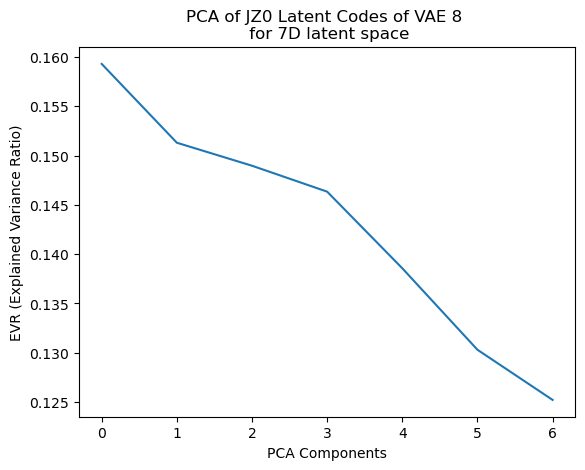

In [10]:
plt.plot(evr)
plt.xlabel("PCA Components")
plt.ylabel("EVR (Explained Variance Ratio)")
plt.title("PCA of JZ0 Latent Codes of VAE 8 \n for 7D latent space")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/notebooks/JZ0_PCA_VAE8.png")

# Normal Distribution?

In [11]:
jz0_chi = np.sum(jz0_latent_codes**2, axis = 1)

In [12]:
chi = np.random.chisquare(7, 49000)
jz0_chi.shape

(49000,)

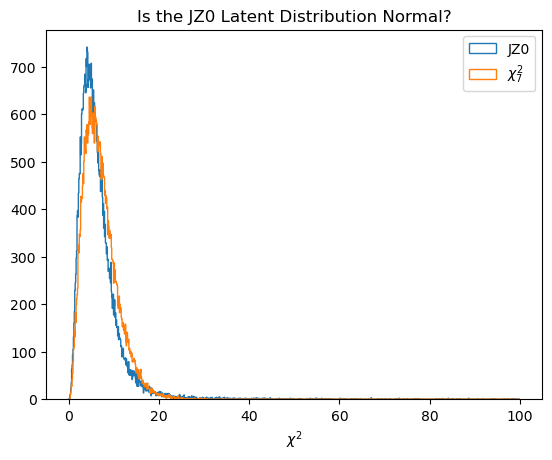

In [48]:
plt.hist(jz0_chi, bins = 1000, range = (0,100), label = "JZ0", histtype= "step")
plt.hist(chi, bins = 1000, range = (0,100), label  = "$\chi^2_7$", histtype= "step")
plt.legend()
plt.xlabel("$\chi^2$")
plt.title("Is the JZ0 Latent Distribution Normal?")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/notebooks/chi_squared_vae8.png")


In [43]:
np.mean(jz0_chi)

6.680835

In [44]:
np.std(jz0_chi)

10.179388

In [ ]:
np.mean(jz0_chi)

### phi invariance

In [49]:
jz0_pi2 = np.load(/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark8/l7/b1e_2/phi_invariance_study/js0pi2kl.npy)

SyntaxError: invalid syntax (307453756.py, line 1)